In [2]:
import xarray as xr
import numpy as np
from random import choice

xr.set_options(keep_attrs=True)

In [15]:
%matplotlib inline

## TODO as of 2019-06-25
* Add instrument info from this http://vocab.nerc.ac.uk/collection/L22/current/
* Add PIs and Participants 
* Add Geometry
* Use EXPOCODE var to record cheif scientists/cruise info?

In [3]:
# This file was made by opening the 2019 I06 bottle file in ODV, and immediately exporting it again
with xr.open_dataset("325020190403_hy1_odv.nc") as f:
    odv_data = f.load()

Things I can think of that need to change from the ODV output:
* rename dims to match argo
* Fix "strings" for the string things
* Fix flag values to be the bytes for 1-9 rather than the ASCII codes for "1"-"9"
* Add standard names and units
* remove empty/unused attrs (comments, units, etc)
* Add all the other attributes we want to use

In [4]:
# renaming dims is super easy
# switch to explicit dim renamer when xarray 0.12.?? lands
renamed_dims = odv_data.rename({"N_SAMPLES": "N_LEVELS", "N_STATIONS": "N_PROF"})

In [5]:
# this fixes the strings "in place" but doesn't actually do anything untill the file is saved
for name, var in renamed_dims.items():
    dtype = var.encoding.get("dtype")
    if np.dtype(dtype).type == np.string_:
        var.encoding["dtype"] = str

In [6]:
# shift the flags to "actual ints"
# requires that "keep_attrs" is True (it really should be)
modified_flags = {}
for name, var in renamed_dims.filter_by_attrs(standard_name=lambda x: x == "status_flag").items():
    modified_flags[name] = var - 48
    modified_flags[name].attrs["flag_values"] = modified_flags[name].attrs["flag_values"] - 48
    modified_flags[name].encoding = var.encoding
    modified_flags[name].encoding["_FillValue"] = 9
modified_flags = renamed_dims.merge(modified_flags, overwrite_vars=modified_flags.keys())

In [7]:
# move long_name to whp_name and units to whp_units
# remove empty units, ignore variables with standard name already
modified_std_names = {}
for name, var in modified_flags.filter_by_attrs(standard_name=lambda x: x is None).items():
    modified_std_names[name] = var.copy()
    modified_std_names[name].attrs["whp_name"] = modified_std_names[name].attrs["long_name"]
    modified_std_names[name].attrs["whp_units"] = modified_std_names[name].attrs["units"]
    if var.attrs["long_name"] in whp_to_stdname:
        modified_std_names[name].attrs["standard_name"] = whp_to_stdname[var.attrs["long_name"]]
        modified_std_names[name].attrs["units"] = whp_to_udunits[var.attrs["long_name"]]
    del modified_std_names[name].attrs["long_name"]
modified_params_units = modified_flags.merge(modified_std_names, overwrite_vars=modified_std_names.keys())


In [8]:
# clear out comments and long_names since we are done with them
# and remove the "_formats" since we potentially have mixed precision
for name, var in modified_params_units.items():
    try:
        del var.attrs["comment"]
    except KeyError:
        pass
    
    try:
        del var.attrs["long_name"]
    except KeyError:
        pass
    
    try:
        del var.attrs["C_format"]
    except KeyError:
        pass
    
    try:
        del var.attrs["FORTRAN_format"]
    except KeyError:
        pass

# clear out an ODV specific thing...
for name, var in modified_params_units.filter_by_attrs(whp_name="Type").items():
    try:
        del modified_params_units[name]
    except KeyError:
        pass

In [9]:
# remove some qc vars for parameters that don't usually have them
no_qc = (
    "CTDPRS",
    "CASTNO",
    "SAMPNO",
    "BTL_LAT",
    "BTL_LON",
    "BTL_TIME",
    "BTL_DATE",
)

for name, var in modified_params_units.filter_by_attrs(whp_name=lambda x: x in no_qc).items():
    try:
        qc_name = var.attrs["ancillary_variables"]
        del modified_params_units[qc_name]
    except KeyError:
        pass
    
    try:
        del var.attrs["ancillary_variables"]
    except KeyError:
        pass

In [10]:
# Now we need to split the ODV "cruise" into the correct whp coordinates of EXPOCODE and SECT_ID
for name, var in modified_params_units.filter_by_attrs(whp_name='Cruise').items(): # should only be one....
    sect_ids = []
    expocodes = []
    for point in var.values: # doing string manipulation in numpy is "hard" lets just use the underlying data
        sect_id, expocode = point.decode('ascii').split('_')
        sect_ids.append(sect_id)
        expocodes.append(expocode)
    sect_ids = xr.DataArray(sect_ids, dims=("N_PROF",), name='sect_id', attrs={"whp_name": "SECT_ID"}) # yes, this one gets a name since it is a "coordinate"
    expocodes = xr.DataArray(expocodes, dims=("N_PROF",), name='expocode', attrs={"whp_name": "EXPOCODE"}) # this one too
    modified_params_units['expocode'] = expocodes
    modified_params_units['sect_id'] = sect_ids
    del modified_params_units[name]

In [11]:
# Fix station number
for name, var in modified_params_units.filter_by_attrs(whp_name='Station').items():
    var.attrs = { "whp_name": "STNNBR" }
    modified_params_units = modified_params_units.rename({name: "stnnbr"})

In [12]:
# add some creator stuff (ACDD):
for whp_param, value in whp_to_createor.items():
    for name, var in modified_params_units.filter_by_attrs(whp_name=whp_param).items():
        var.attrs["creator_name"] = value
        if isinstance(value, str):
            var.attrs["creator_email"] = creator_emails[value]
            var.attrs["creator_type"] = "person"
        else:
            var.attrs["creator_email"] = [creator_emails[creator] for creator in value]
            var.attrs["creator_type"] = ["person" for creator in value]
    # fake some processing levels?
    var.attrs["processing_level"] = choice(['final', 'preliminary'])
    if np.all(np.isnan(var.values)):
        var.attrs["processing_level"] = choice(["not_received", "pending_merge"])

In [276]:
modified_params_units.to_netcdf('cchdo_option1.nc')

In [1]:
## custom data for this specific example file



whp_to_stdname = {
"CTDPRS": "sea_water_pressure",
"CTDTMP": "sea_water_temperature",
"CTDSAL": "sea_water_practical_salinity",
"SALNTY": "sea_water_practical_salinity",
"OXYGEN": "moles_of_oxygen_per_unit_mass_in_sea_water",
"PHSPHT": "moles_of_phosphate_per_unit_mass_in_sea_water",
"SILCAT": "moles_of_silicate_per_unit_mass_in_sea_water",
"NITRAT": "moles_of_nitrate_per_unit_mass_in_sea_water",
"NITRIT": "moles_of_nitrite_per_unit_mass_in_sea_water",
"CFC-11": "moles_of_cfc11_per_unit_mass_in_sea_water",
"CFC-12": "moles_of_cfc12_per_unit_mass_in_sea_water", # not in CF List
"SF6": "moles_of_sf6_per_unit_mass_in_sea_water", # not in CF list
"ALKALI": "sea_water_alkalinity_expressed_as_molal_equivalent", # not in CF
"TCARBN": "moles_of_dissolved_inorganic_carbon_per_unit_mass_in_sea_water", # not in CF
"PH_TOT": "sea_water_ph_reported_on_total_scale",
"DOC": "moles_of_dissolved_organic_carbon_per_unit_mass_in_sea_water", # not in CF
"TOC": "moles_of_organic_carbon_per_unit_mass_in_sea_water", # not in CF
"DON": "moles_of_organic_nitrogen_per_unit_mass_in_sea_water", # not in CF
"TDN": "moles_of_dissolved_organic_nitrogen_per_unit_mass_in_sea_water",
"DELC14": "enrichment_of_14C_in_carbon_dioxide_in_sea_water_expressed_as_uppercase_delta_14C",
"DELC13": "enrichment_of_13C_in_carbon_dioxide_in_sea_water_expressed_as_uppercase_delta_13C", #not in CF
"DELO18": "enrichment_of_18O_in_water_in_sea_water_expressed_as_uppercase_delta_18O", # not in CF (guess)
"CTDOXY": "moles_of_oxygen_per_unit_mass_in_sea_water",
"PH_TMP": "sea_water_analysis_temperature", #not in CF (need to ask)
"N2O": "moles_of_n2o_per_unit_mass_in_sea_water", #not in CF
"REFTMP": "sea_water_temperature",
"CTDBACKSCATTER": "volume_backwards_scattering_coefficient_of_radiative_flux_in_sea_water", #need to check final units... but volts
"CTDFLUOR": "mass_concentration_of_chlorophyll_a_in_sea_water",
"CTDXMISS": "volume_beam_attenuation_coefficient_of_radiative_flux_in_sea_water_corrected_for_pure_water_attenuance",
"BTL_LON": "longitude",
"BTL_LAT": "latitude",
}
whp_to_udunits = {
"CTDPRS": "dbar",
"CTDTMP": "degc",
"CTDSAL": "1",
"SALNTY": "1",
"OXYGEN": "umol kg-1",
"PHSPHT": "umol kg-1",
"SILCAT": "umol kg-1",
"NITRAT": "umol kg-1",
"NITRIT": "umol kg-1",
"CFC-11": "pmol kg-1",
"CFC-12": "pmol kg-1", # not in CF List
"SF6": "fmol kg-1", # not in CF list
"ALKALI": "umol kg-1", # not in CF
"TCARBN": "umol kg-1", # not in CF
"PH_TOT": "1",
"DOC": "umol kg-1", # not in CF
"TOC": "umol kg-1", # not in CF
"DON": "umol kg-1", # not in CF
"TDN": "umol kg-1",
"DELC14": "0.001",
"DELC13": "0.001", #not in CF
"DELO18": "0.001", # not in CF (guess)
"CTDOXY": "umol kg-1",
"PH_TMP": "degc", #not in CF (need to ask)
"N2O": "nmol kg-1", #not in CF
"REFTMP": "degc",
"CTDBACKSCATTER": "volts", #need to check final units... but volts
"CTDFLUOR": "volts",
"CTDXMISS": "volts",
"BTL_LON": "degrees_east",
"BTL_LAT": "degrees_north",
}
whp_to_createor = {
"CTDPRS": ["Susan Becker", "Jim Swift"],
"CTDTMP": ["Susan Becker", "Jim Swift"],
"CTDSAL": ["Susan Becker", "Jim Swift"],
"SALNTY": ["Susan Becker", "Jim Swift"],
"OXYGEN": ["Susan Becker", "Jim Swift"],
"PHSPHT": ["Susan Becker", "Jim Swift"],
"SILCAT": ["Susan Becker", "Jim Swift"],
"NITRAT": ["Susan Becker", "Jim Swift"],
"NITRIT": ["Susan Becker", "Jim Swift"],
"CFC-11": "Dong-Ha Min",
"CFC-12": "Dong-Ha Min", # not in CF List
"SF6": "Dong-Ha Min", # not in CF list
"ALKALI": "Andrew Dickson", # not in CF
"TCARBN": ["Dana Greely", "Rik Wanninkhof"], # not in CF
"PH_TOT": "Andrew Dickson",
"DOC": "Dennis Hansell", # not in CF
"TOC": "Dennis Hansell", # not in CF
"DON": "Dennis Hansell", # not in CF
"TDN": "Dennis Hansell",
"DELC14": ["Ann McNichol","Robert Key"],
"DELC13": ["Ann McNichol","Robert Key"], #not in CF
"DELO18": "Mike Meredith", # not in CF (guess)
"CTDOXY": ["Susan Becker", "Jim Swift"],
"PH_TMP": "Andrew Dickson", #not in CF (need to ask)
"N2O": "Dong-Ha Min", #not in CF
"REFTMP": ["Susan Becker", "Jim Swift"],
"CTDBACKSCATTER": "Emmanuel Boss", #need to check final units... but volts
"CTDFLUOR": "Emmanuel Boss",
"CTDXMISS": "Wilf Gardner",
}
creator_emails = {
    "Susan Becker": "sbecker@ucsd.edu",
    "Jim Swift": "jswift@ucsd.edu",
    "Dong-Ha Min": "dongha@mail.utexas.edu",
    "Andrew Dickson": "adickson@ucsd.edu",
    "Dana Greely": "dana.greeley@noaa.gov",
    "Rik Wanninkhof": "Rik.Wanninkhof@noaa.gov",
    "Dennis Hansell": "dhansell@rsmas.miami.edu",
    "Ann McNichol": "amcnichol@whoi.edu",
    "Robert Key": "key@princeton.edu",
    "Mike Meredith": "mmm@bas.ac.uk",
    "Emmanuel Boss": "emmanuel.boss@maine.edu",
    "Wilf Gardner": "wgardner@ocean.tamu.edu",
}

In [277]:
!ncdump -h cchdo_option1.nc

netcdf cchdo_option1 {
dimensions:
	N_PROF = 55 ;
	N_LEVELS = 36 ;
variables:
	string stnnbr(N_PROF) ;
		stnnbr:whp_name = "STNNBR" ;
	float longitude(N_PROF) ;
		longitude:_FillValue = -1.e+10f ;
		longitude:standard_name = "longitude" ;
		longitude:units = "degrees_east" ;
	float latitude(N_PROF) ;
		latitude:_FillValue = -1.e+10f ;
		latitude:standard_name = "latitude" ;
		latitude:units = "degrees_north" ;
	double date_time(N_PROF) ;
		date_time:_FillValue = -10000000000. ;
		date_time:standard_name = "time" ;
		date_time:units = "days since 2019-01-01T00:00:00+00:00" ;
		date_time:calendar = "proleptic_gregorian" ;
	float var1(N_PROF, N_LEVELS) ;
		var1:_FillValue = -1.e+10f ;
		var1:positive = "down" ;
		var1:units = "dbar" ;
		var1:whp_name = "CTDPRS" ;
		var1:whp_units = "DBAR" ;
		var1:standard_name = "sea_water_pressure" ;
		string var1:creator_name = "Susan Becker", "Jim Swift" ;
		string var1:creator_email = "sbecker@ucsd.edu", "jswift@ucsd.edu" ;
		string var1:creator_type

In [278]:
!ncdump -h 325020190403_hy1_odv.nc

netcdf \325020190403_hy1_odv {
dimensions:
	N_STATIONS = 55 ;
	N_SAMPLES = 36 ;
	STRING17 = 17 ;
	STRING20 = 20 ;
	STRING2 = 2 ;
variables:
	char metavar1(N_STATIONS, STRING17) ;
		metavar1:long_name = "Cruise" ;
		metavar1:units = "" ;
		metavar1:comment = "" ;
	char metavar2(N_STATIONS, STRING20) ;
		metavar2:long_name = "Station" ;
		metavar2:units = "" ;
		metavar2:comment = "" ;
	char metavar3(N_STATIONS) ;
		metavar3:long_name = "Type" ;
		metavar3:units = "" ;
		metavar3:comment = "" ;
	float longitude(N_STATIONS) ;
		longitude:long_name = "Longitude" ;
		longitude:standard_name = "longitude" ;
		longitude:units = "degrees_east" ;
		longitude:comment = "" ;
		longitude:C_format = "%.3f" ;
		longitude:FORTRAN_format = "F12.3" ;
		longitude:_FillValue = -1.e+10f ;
	float latitude(N_STATIONS) ;
		latitude:long_name = "Latitude" ;
		latitude:standard_name = "latitude" ;
		latitude:units = "degrees_north" ;
		latitude:comment = "" ;
		latitude:C_format = "%.3f" ;
		latitude:FORTRAN_f

In [13]:
@xr.register_dataset_accessor('cchdo')
class CCHDOAccessor:
    def __init__(self, xarray_obj):
        self._obj = xarray_obj
        
    def argo_param_names(self):
        cf_stdname_to_argo = { #taken direcly from whatever that argo param name list is
            "sea_water_pressure": "PRES",
            "sea_water_practical_salinity": "PSAL",
            "sea_water_temperature": "TEMP",
            "moles_of_oxygen_per_unit_mass_in_sea_water": "DOXY",
            "moles_of_nitrate_per_unit_mass_in_sea_water": "NITRATE",
            "sea_water_ph_reported_on_total_scale": "PH_IN_SITU_TOTAL",
        }
        # from Argo Data Management Team (2017). Argo user’s manual V3.2. https://doi.org/10.13155/29825 section 3.3.1:
        # > Some floats are equipped with 2 different sensors, measuring the same physical parameter. In that
        # > case, add the integer "2" at the end of the code of the duplicate parameter (e.g. DOXY2).
        # > If more  sensors that measure the same physical parameter are added, then the integer will simply
        # > increase by 1 (i.e. DOXY3, DOXY4, and so on).
        
        rename_mapping = {}
        for std_name, argo_name in cf_stdname_to_argo.items():
            for count, (name, var) in enumerate(self._obj.filter_by_attrs(standard_name=std_name).items(), start=1):
                if count > 1:
                    argo_name = f"{argo_name}{count}"
                rename_mapping[name] = argo_name
                
        argo_vname_ds = self._obj.rename(rename_mapping)
        
        # update QC varnames and the CF ancillary_variables attr
        rename_mapping_qc = {}
        for name in rename_mapping.values():
            ancilary_vars = argo_vname_ds[name].attrs.get("ancillary_variables", "").split()
            for var in ancilary_vars:
                #TODO make this work for multiple status flag fields per var
                # we *only* care about status flags
                if "status_flag" not in argo_vname_ds[var].attrs.get("standard_name", ""):
                    continue
                    
                rename_mapping_qc[var] = f"{name}_QC"
        # DO QC rename
        argo_vname_ds = argo_vname_ds.rename(rename_mapping_qc)
    
        for key, value in rename_mapping_qc.items():
            for name, var in argo_vname_ds.filter_by_attrs(ancillary_variables=lambda x: x is not None and key in x ).items():
                var.attrs['ancillary_variables'] = var.attrs['ancillary_variables'].replace(key, value)
        return argo_vname_ds
    
    def whp_param_names(self):
        pass
    

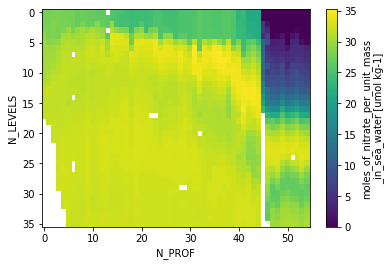

In [27]:
modified_params_units.cchdo.argo_param_names().NITRATE.T.plot(yincrease=False)

In [285]:
!ncdump -h with_argonames.nc

netcdf with_argonames {
dimensions:
	N_PROF = 55 ;
	N_LEVELS = 36 ;
variables:
	string stnnbr(N_PROF) ;
		stnnbr:whp_name = "STNNBR" ;
	float longitude(N_PROF) ;
		longitude:_FillValue = -1.e+10f ;
		longitude:standard_name = "longitude" ;
		longitude:units = "degrees_east" ;
	float latitude(N_PROF) ;
		latitude:_FillValue = -1.e+10f ;
		latitude:standard_name = "latitude" ;
		latitude:units = "degrees_north" ;
	double date_time(N_PROF) ;
		date_time:_FillValue = -10000000000. ;
		date_time:standard_name = "time" ;
		date_time:units = "days since 2019-01-01T00:00:00+00:00" ;
		date_time:calendar = "proleptic_gregorian" ;
	float PRES(N_PROF, N_LEVELS) ;
		PRES:_FillValue = -1.e+10f ;
		PRES:positive = "down" ;
		PRES:units = "dbar" ;
		PRES:whp_name = "CTDPRS" ;
		PRES:whp_units = "DBAR" ;
		PRES:standard_name = "sea_water_pressure" ;
		string PRES:creator_name = "Susan Becker", "Jim Swift" ;
		string PRES:creator_email = "sbecker@ucsd.edu", "jswift@ucsd.edu" ;
		string PRES:creator_typ

In [304]:
modified_params_units.cchdo.argo_param_names()

<xarray.Dataset>
Dimensions:              (N_LEVELS: 36, N_PROF: 55)
Dimensions without coordinates: N_LEVELS, N_PROF
Data variables:
    stnnbr               (N_PROF) |S20 b'1' b'2' b'3' b'4' ... b'53' b'54' b'55'
    longitude            (N_PROF) float32 31.5344 31.3952 ... 29.798 29.9988
    latitude             (N_PROF) float32 -68.342 -68.354 ... -38.02 -38.5079
    date_time            (N_PROF) datetime64[ns] 2019-04-16T09:06:59.999995082 ... 2019-05-11T17:59:00.000003576
    PRES                 (N_PROF, N_LEVELS) float32 5.4 20.1 ... 4266.0 4360.0
    TEMP                 (N_PROF, N_LEVELS) float32 -1.8123 -1.8075 ... 1.0751
    TEMP_QC              (N_PROF, N_LEVELS) float32 2.0 2.0 2.0 ... 2.0 2.0 2.0
    var3                 (N_PROF, N_LEVELS) float32 33.9085 33.9103 ... 34.7324
    var3_qc              (N_PROF, N_LEVELS) float32 2.0 2.0 2.0 ... 2.0 2.0 2.0
    var4                 (N_PROF, N_LEVELS) float32 33.9047 33.902 ... 34.7298
    var4_qc              (N_PROF, N_LEVE